<a href="https://colab.research.google.com/github/Gaby-ia/Proyecto_COLAB_UIDE/blob/main/ProyectoIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librerías

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [ ]:
# Parámetros de la base de datos
num_classes = 10
input_shape = (28, 28, 1)
# Cargar los datos y dividirlos en los sets necesarios
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Escalar las imagenes entre [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Añadir una dimensión para el modelo (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(x_train.shape[0], "Cantidad de muestras para entrenamiento")
print(x_test.shape[0], "Cantidad de muestras para pruebas")

# Convertir las clases a un sistema de salida
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
60000 Cantidad de muestras para entrenamiento
10000 Cantidad de muestras para pruebas


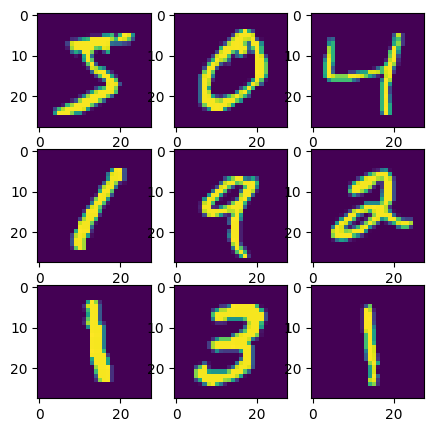

In [ ]:
# Visualizar los datos

plt.figure(figsize=(5,5))
for i in range(0,9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i].reshape((28,28)))
plt.show()


In [ ]:
#Construir el modelo

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(6, kernel_size=(5, 5), activation="relu", padding = 'valid'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(16, kernel_size=(5, 5), activation="relu", padding = 'valid'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(256),
        layers.Dense(100),
        layers.Dense(100),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,174 (410.84 KB)

 Trainable params: 105,174 (410.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar el modelo

batch_size = 100
epochs = 3

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)



Epoch 1/3
540/540 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.9295 - loss: 0.2279 - val_accuracy: 0.9772 - val_loss: 0.0767
Epoch 2/3
540/540 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9768 - loss: 0.0748 - val_accuracy: 0.9813 - val_loss: 0.0641
Epoch 3/3
540/540 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.9808 - loss: 0.0603 - val_accuracy: 0.9843 - val_loss: 0.0517


In [ ]:
# Evaluar el modelo

score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.040742501616477966
Test accuracy: 0.9873999953269958


In [ ]:
x_test[0].shape

(28, 28, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Prediccion:  7
Real:  7


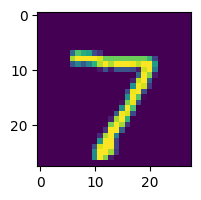

Prediccion:  2
Real:  2


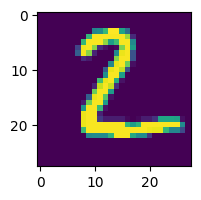

Prediccion:  1
Real:  1


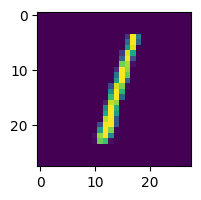

Prediccion:  0
Real:  0


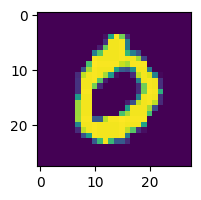

Prediccion:  4
Real:  4


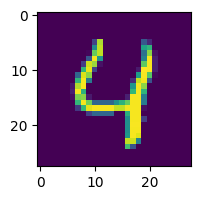

Prediccion:  1
Real:  1


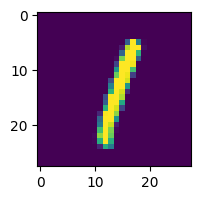

Prediccion:  4
Real:  4


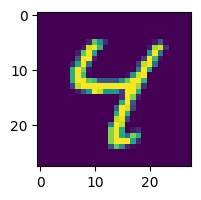

Prediccion:  9
Real:  9


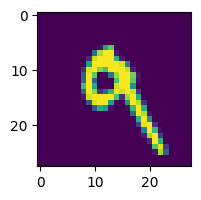

Prediccion:  5
Real:  5


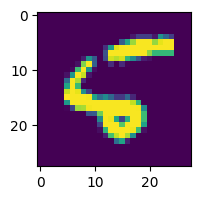

In [ ]:
# Ver los resultados de testing
resultados = model.predict(x_test[0:9])
for i in range(0,9):
  print('Prediccion: ',resultados[i].argmax())
  print('Real: ', y_test[i].argmax())
  plt.figure(figsize=(2,2))
  plt.imshow(x_test[i].reshape((28,28)))
  plt.show()


